In [1]:
import pandas as pd
import numpy as np

df_orders = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

df_orders['purchase_hour'] = df_orders['order_purchase_timestamp'].dt.hour
df_orders['purchase_dow'] = df_orders['order_purchase_timestamp'].dt.dayofweek

# ==================== 1. 单变量分析 (Univariate Analysis) ====================
print("=== 1.1 订单状态分布 ===")
print(df_orders['order_status'].value_counts())
print("\n" + "="*50 + "\n")

print("=== 1.2 支付渠道分布 ===")
print(df_payments['payment_type'].value_counts())
print("\n" + "="*50 + "\n")

print("=== 1.3 支付金额描述性统计 ===")
print(df_payments['payment_value'].describe())
print("\n" + "="*50 + "\n")

# ==================== 2. 双变量分析 (Bivariate Analysis) ====================
print("=== 2.1 支付渠道 vs 支付金额 (分组聚合) ===")
print(df_payments.groupby('payment_type')['payment_value'].agg(['count', 'mean', 'median', 'sum']))
print("\n" + "="*50 + "\n")

print("=== 2.2 订单价格 vs 运费金额 (相关性分析) ===")
df_financial = df_items.groupby('order_id')[['price', 'freight_value']].sum()
print(df_financial.corr(method='pearson'))
print("\n" + "="*50 + "\n")

print("=== 2.3 支付渠道 vs 分期期数 (交叉制表) ===")
print(pd.crosstab(df_payments['payment_type'], df_payments['payment_installments']))
print("\n" + "="*50 + "\n")

# ==================== 3. 三变量分析 (Multivariate Analysis) ====================
print("=== 3.1 星期几 x 一天24小时 x 订单量矩阵 (7x24热力基准) ===")
matrix_7x24 = pd.crosstab(
    index=df_orders['purchase_dow'],
    columns=df_orders['purchase_hour'],
    values=df_orders['order_id'],
    aggfunc='count'
).fillna(0).astype(int)
matrix_7x24.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(matrix_7x24)
print("\n" + "="*50 + "\n")

print("=== 3.2 支付渠道 x 分期期数 x 平均支付金额 ===")
matrix_multiv = df_payments.pivot_table(
    index='payment_type',
    columns='payment_installments',
    values='payment_value',
    aggfunc='mean'
).round(2).fillna(0)
print(matrix_multiv)

=== 1.1 订单状态分布 ===
order_status
delivered      94834
shipped         1096
canceled         617
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


=== 1.2 支付渠道分布 ===
payment_type
credit_card    75478
boleto         19488
voucher         5697
debit_card      1482
Name: count, dtype: int64


=== 1.3 支付金额描述性统计 ===
count    102145.000000
mean        154.324144
std         218.119957
min           0.010000
25%          56.820000
50%         100.000000
75%         171.960000
max       13664.080000
Name: payment_value, dtype: float64


=== 2.1 支付渠道 vs 支付金额 (分组聚合) ===
              count        mean   median          sum
payment_type                                         
boleto        19488  145.356337   94.195   2832704.30
credit_card   75478  163.553883  106.890  12344720.00
debit_card     1482  142.704521   89.020    211488.10
voucher        5697   65.741150   39.090    374527.33


=== 2.2 订单价格 vs 运费金额 (相关性分

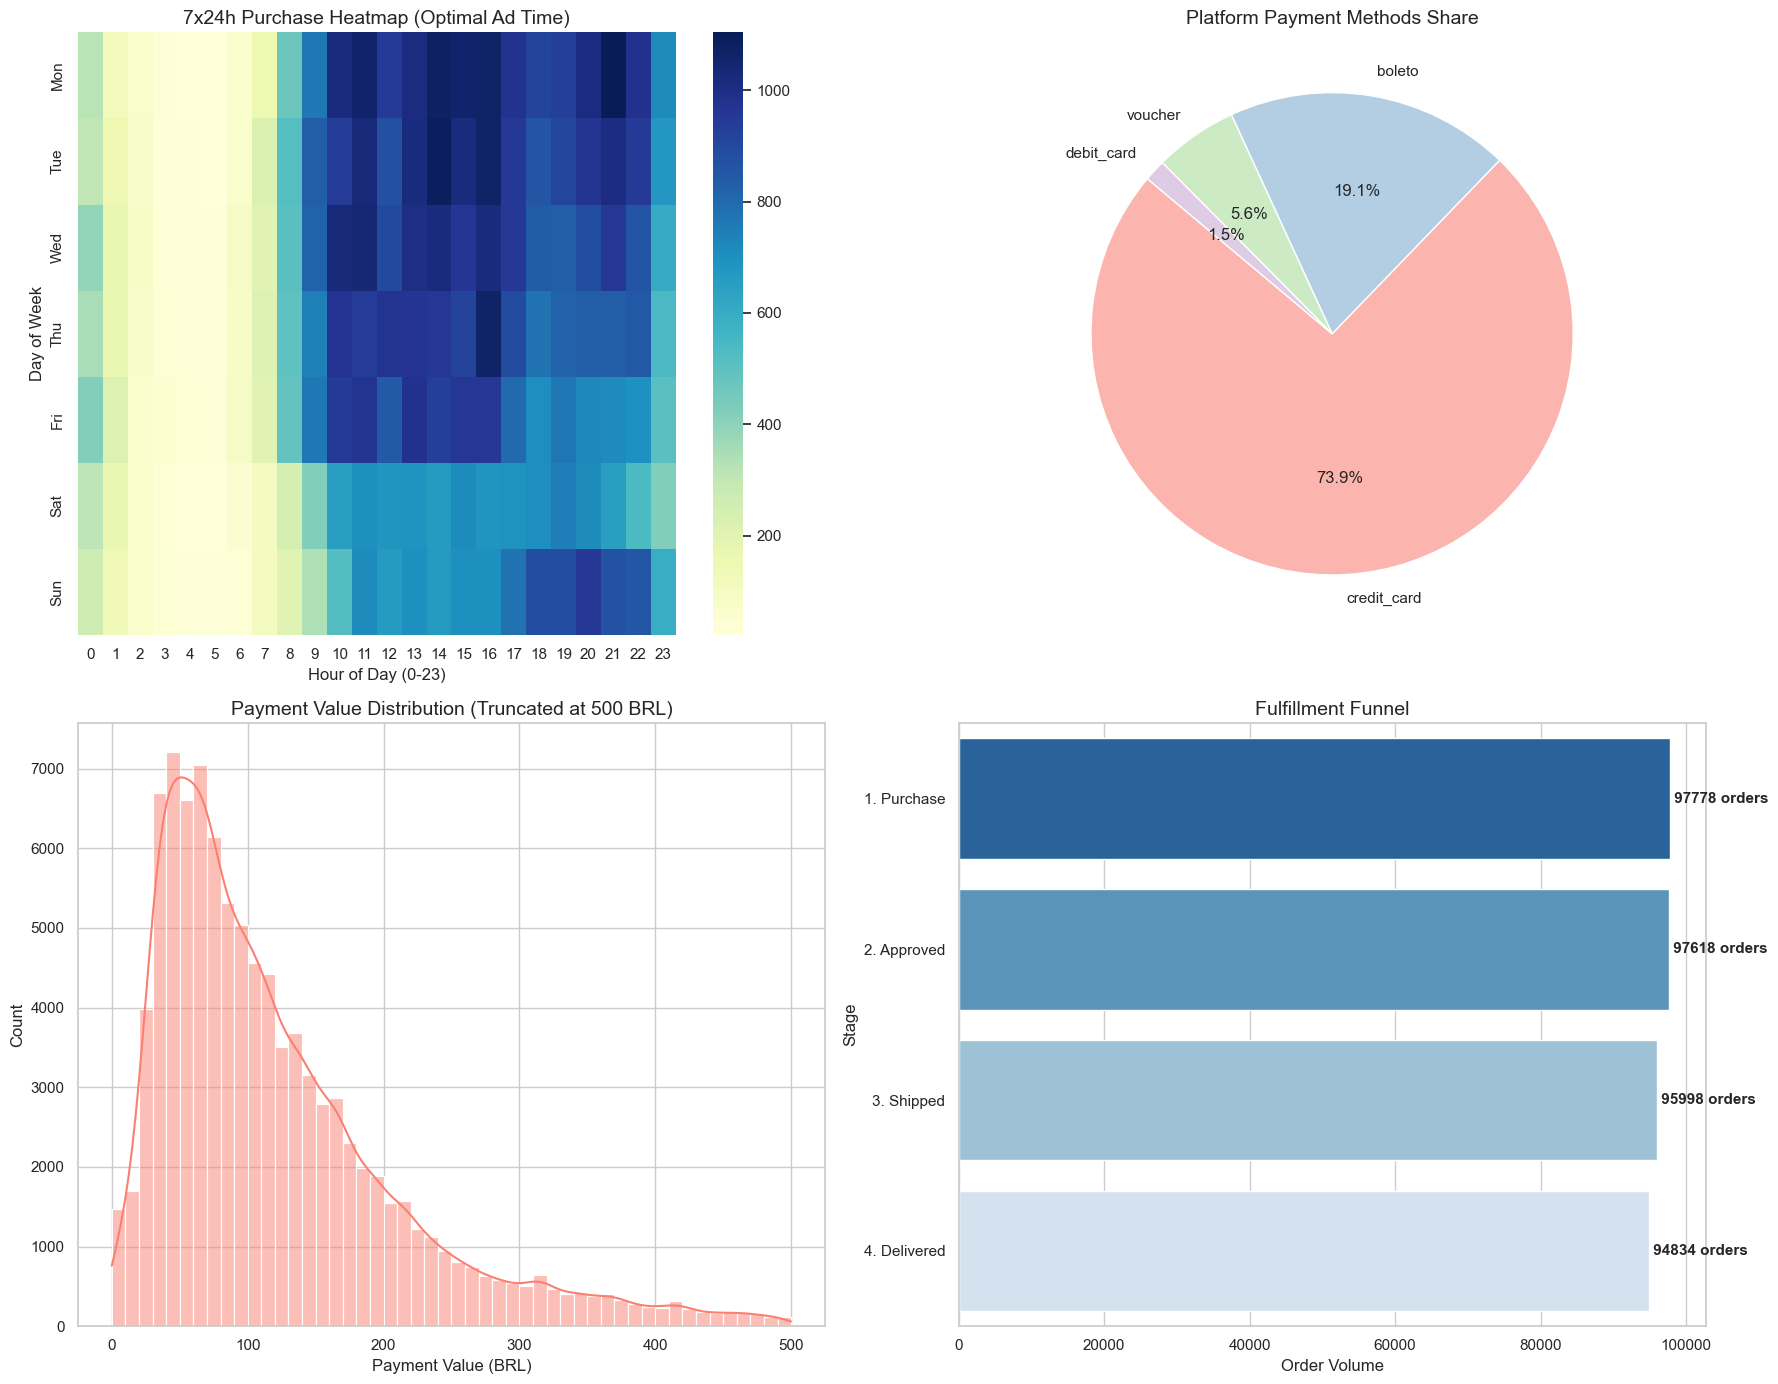

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

matrix_7x24 = pd.crosstab(index=df_orders['purchase_dow'], columns=df_orders['purchase_hour'])
matrix_7x24.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.heatmap(matrix_7x24, cmap="YlGnBu", annot=False, ax=axes[0, 0])
axes[0, 0].set_title("7x24h Purchase Heatmap (Optimal Ad Time)", fontsize=14)
axes[0, 0].set_xlabel("Hour of Day (0-23)", fontsize=12)
axes[0, 0].set_ylabel("Day of Week", fontsize=12)

pay_counts = df_payments['payment_type'].value_counts()
axes[0, 1].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=140,
               colors=sns.color_palette("Pastel1"))
axes[0, 1].set_title("Platform Payment Methods Share", fontsize=14)

sns.histplot(df_payments[df_payments['payment_value'] <= 500]['payment_value'],
             kde=True, color="salmon", ax=axes[1, 0], bins=50)
axes[1, 0].set_title("Payment Value Distribution (Truncated at 500 BRL)", fontsize=14)
axes[1, 0].set_xlabel("Payment Value (BRL)", fontsize=12)

funnel_stages = {
    "1. Purchase": df_orders['order_purchase_timestamp'].notnull().sum(),
    "2. Approved": df_orders['order_approved_at'].notnull().sum(),
    "3. Shipped": df_orders['order_delivered_carrier_date'].notnull().sum(),
    "4. Delivered": df_orders['order_delivered_customer_date'].notnull().sum()
}
df_funnel = pd.DataFrame(list(funnel_stages.items()), columns=['Stage', 'Count'])
sns.barplot(x='Count', y='Stage', data=df_funnel, hue='Stage', palette="Blues_r", legend=False, ax=axes[1, 1])

for index, value in enumerate(df_funnel['Count']):
    axes[1, 1].text(value, index, f' {value} orders', va='center', fontsize=11, fontweight='bold')
axes[1, 1].set_title("Fulfillment Funnel", fontsize=14)
axes[1, 1].set_xlabel("Order Volume", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
from scipy import stats

df_orders = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments = pd.read_parquet("../data/processed/olist_payments_clean.parquet")

# ==================== 1. 双变量分析: 连续 vs 连续 (Spearman秩相关) ====================
corr_val, p_val_corr = stats.spearmanr(df_payments['payment_value'], df_payments['payment_installments'])
print("=== 1.1 Spearman Correlation ===")
print(f"Correlation Coefficient: {corr_val:.4f}")
print(f"P-value: {p_val_corr}")
print("\n" + "="*50 + "\n")

# ==================== 2. 双变量分析: 离散 vs 连续 (独立样本 t 检验) ====================
cc_vals = df_payments[df_payments['payment_type'] == 'credit_card']['payment_value']
bl_vals = df_payments[df_payments['payment_type'] == 'boleto']['payment_value']
t_stat, p_val_t = stats.ttest_ind(cc_vals, bl_vals, equal_var=False)
print("=== 2.1 Independent T-Test ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t}")
print("\n" + "="*50 + "\n")

# ==================== 3. 双变量分析: 离散 vs 离散 (卡方独立性检验) ====================
df_orders['on_time'] = df_orders['order_delivered_customer_date'] <= df_orders['order_estimated_delivery_date']
df_merged = pd.merge(df_payments, df_orders[['order_id', 'on_time']], on='order_id', how='inner')
contingency_table = pd.crosstab(df_merged['payment_type'], df_merged['on_time'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print("=== 3.1 Chi-Square Test ===")
print(contingency_table)
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p_val_chi2}")
print("\n" + "="*50 + "\n")

# ==================== 4. 多变量分析: 引入控制变量进行分层时序矩阵 ====================
df_orders['purchase_hour'] = df_orders['order_purchase_timestamp'].dt.hour
df_orders['purchase_dow'] = df_orders['order_purchase_timestamp'].dt.dayofweek
df_multiv_merged = pd.merge(df_orders, df_payments, on='order_id', how='inner')

print("=== 4.1 Stratified 7x24 Matrix (Control: Credit Card Only) ===")
matrix_cc = pd.crosstab(
    index=df_multiv_merged[df_multiv_merged['payment_type'] == 'credit_card']['purchase_dow'],
    columns=df_multiv_merged[df_multiv_merged['payment_type'] == 'credit_card']['purchase_hour']
)
matrix_cc.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(matrix_cc)
print("\n" + "="*50 + "\n")

print("=== 4.2 Stratified 7x24 Matrix (Control: Boleto Only) ===")
matrix_bl = pd.crosstab(
    index=df_multiv_merged[df_multiv_merged['payment_type'] == 'boleto']['purchase_dow'],
    columns=df_multiv_merged[df_multiv_merged['payment_type'] == 'boleto']['purchase_hour']
)
matrix_bl.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(matrix_bl)

=== 1.1 Spearman Correlation ===
Correlation Coefficient: 0.4117
P-value: 0.0


=== 2.1 Independent T-Test ===
T-statistic: 10.4840
P-value: 1.1286012314716238e-25


=== 3.1 Chi-Square Test ===
on_time       False  True 
payment_type              
boleto         2285  17203
credit_card    8074  67404
debit_card      156   1326
voucher         652   5045
Chi2 Statistic: 18.6538
P-value: 0.0003223713914520467


=== 4.1 Stratified 7x24 Matrix (Control: Credit Card Only) ===
purchase_hour   0    1   2   3   4   5   6    7    8    9   ...   14   15  \
Mon            249   98  52  31  14  16  49  105  336  545  ...  813  787   
Tue            228  110  60  15  19  16  51  159  368  596  ...  817  747   
Wed            305  132  62  17  25  18  73  142  381  585  ...  765  714   
Thu            264  125  58  25  25  23  58  153  363  529  ...  709  675   
Fri            324  167  57  29  25  23  67  157  342  563  ...  697  760   
Sat            253  138  47  24  19  18  39   89  192  330  ..

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

df_orders = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

df_orders['t_purchase'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['t_approved'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['t_carrier'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['t_customer'] = pd.to_datetime(df_orders['order_delivered_customer_date'])

df_orders['days_approval'] = (df_orders['t_approved'] - df_orders['t_purchase']).dt.total_seconds() / 86400
df_orders['days_packing'] = (df_orders['t_carrier'] - df_orders['t_approved']).dt.total_seconds() / 86400
df_orders['days_delivery'] = (df_orders['t_customer'] - df_orders['t_carrier']).dt.total_seconds() / 86400
df_orders['days_total_fulfillment'] = (df_orders['t_customer'] - df_orders['t_purchase']).dt.total_seconds() / 86400

print(df_orders[['days_approval', 'days_packing', 'days_delivery', 'days_total_fulfillment']].describe())
print("\n" + "="*50 + "\n")

df_geo_orders = pd.merge(df_orders, df_customers[['customer_id', 'customer_state']], on='customer_id', how='inner')

print(df_geo_orders.groupby('customer_state')['days_total_fulfillment'].median().sort_values(ascending=False))
print("\n" + "="*50 + "\n")

sp_delivery = df_geo_orders[df_geo_orders['customer_state'] == 'SP']['days_total_fulfillment'].dropna()
rj_delivery = df_geo_orders[df_geo_orders['customer_state'] == 'RJ']['days_total_fulfillment'].dropna()

t_stat_geo, p_val_geo = stats.ttest_ind(sp_delivery, rj_delivery, equal_var=False)
print(t_stat_geo)
print(p_val_geo)

       days_approval  days_packing  days_delivery  days_total_fulfillment
count   97618.000000  95984.000000   94833.000000            94834.000000
mean        0.408899      2.854131       9.338168               12.589655
std         1.043483      3.476660       8.508909                9.318136
min         0.000000      0.000174       0.000000                0.533414
25%         0.008935      0.900992       4.110961                6.810313
50%         0.014086      1.850087       7.108900               10.268987
75%         0.569210      3.619957      12.054259               15.795376
max       187.882523    125.762569     172.956597              175.223819


customer_state
AM    25.849479
RR    25.131105
AP    24.220584
AL    22.325845
PA    21.093171
MA    19.242888
AC    18.499502
CE    18.225440
PB    18.204606
SE    18.014306
RO    17.582361
BA    16.947153
PI    16.377049
MT    16.144097
RN    16.060255
TO    15.921412
PE    15.737049
GO    13.986840
MS    13.964155
ES    13.7232

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# ==================== [基底构筑] 1. 多表级联，打造全维分析主表 (ABT) ====================
df_orders = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# 时间特征增强
df_orders['purchase_dt'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['purchase_month'] = df_orders['purchase_dt'].dt.to_period('M')
df_orders['purchase_hour'] = df_orders['purchase_dt'].dt.hour
df_orders['purchase_dow'] = df_orders['purchase_dt'].dt.dayofweek
df_orders['days_total_fulfillment'] = (pd.to_datetime(df_orders['order_delivered_customer_date']) - df_orders['purchase_dt']).dt.total_seconds() / 86400

# 拼装人、货、场全维大表
df_master = pd.merge(df_orders, df_customers, on='customer_id', how='inner')
df_master = pd.merge(df_master, df_items, on='order_id', how='inner')
df_master = pd.merge(df_master, df_products[['product_id', 'product_category_name', 'product_weight_g']], on='product_id', how='inner')

# ==================== [货的关联] 2. 购物篮联合消费矩阵 (Market Basket Co-occurrence) ====================
print("=== 2.1 跨品类购物篮协同矩阵 (Top 5 黄金搭档) ===")
# 过滤掉单笔订单只有单件商品的记录，寻找同一个order_id下共同出现的不同品类
df_basket = df_master[['order_id', 'product_category_name']].drop_duplicates()
df_basket_merged = pd.merge(df_basket, df_basket, on='order_id', suffixes=('_A', '_B'))
# 剔除自己跟自己的组合，且保证A!=B防止重复计数
df_pairs = df_basket_merged[df_basket_merged['product_category_name_A'] != df_basket_merged['product_category_name_B']]
co_occurrence = df_pairs.groupby(['product_category_name_A', 'product_category_name_B']).size().sort_values(ascending=False)
print(co_occurrence.head(10))
print("\n" + "="*60 + "\n")

# ==================== [人的留存] 3. 月度群组留存阵列 (Cohort Retention Analysis) ====================
print("=== 3.1 用户群组月度留存阵列 (Cohort Matrix) ===")
# 锁定用户唯一ID：customer_unique_id
df_user_timeline = df_master[['customer_unique_id', 'purchase_month']].drop_duplicates()
# 算每个用户的“初次破处”购买月份（首购月）
df_user_timeline['first_purchase_month'] = df_user_timeline.groupby('customer_unique_id')['purchase_month'].transform('min')
# 计算每一笔订单相对于首购月的月份差（Cohort Index）
df_user_timeline['cohort_index'] = (df_user_timeline['purchase_month'].dt.year - df_user_timeline['first_purchase_month'].dt.year) * 12 + (df_user_timeline['purchase_month'].dt.month - df_user_timeline['first_purchase_month'].dt.month)

cohort_data = df_user_timeline.groupby(['first_purchase_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='first_purchase_month', columns='cohort_index', values='customer_unique_id').fillna(0).astype(int)
# 转化为百分比留存矩阵
cohort_size = cohort_pivot.iloc[:, 0]
cohort_matrix = cohort_pivot.divide(cohort_size, axis=0).round(4) * 100
print(cohort_matrix.head(10))
print("\n" + "="*60 + "\n")

# ==================== [场预测] 4. 供应链瓶颈特征工程与机器学习回归 (Predictive ML Pipeline) ====================
print("=== 4.1 机器学习管线：供应链耗时预测与核心特征排查 ===")
# 构建预测数据集：剔除尚未妥投的缺失记录
df_ml = df_master[['days_total_fulfillment', 'price', 'freight_value', 'product_weight_g', 'purchase_hour', 'purchase_dow', 'customer_state']].dropna()
# 独热编码处理地域离散变量
df_ml_encoded = pd.get_dummies(df_ml, columns=['customer_state'], drop_first=True)

X = df_ml_encoded.drop(columns=['days_total_fulfillment'])
y = df_ml_encoded['days_total_fulfillment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("👉 决定平台物流卡点/耗时的 Top 5 核心驱动特征权重:")
print(feature_importances.head(5))

=== 2.1 跨品类购物篮协同矩阵 (Top 5 黄金搭档) ===
product_category_name_A  product_category_name_B
cama_mesa_banho          moveis_decoracao           68
moveis_decoracao         cama_mesa_banho            68
casa_conforto            cama_mesa_banho            42
cama_mesa_banho          casa_conforto              42
utilidades_domesticas    moveis_decoracao           23
moveis_decoracao         utilidades_domesticas      23
cama_mesa_banho          utilidades_domesticas      20
cool_stuff               bebes                      20
utilidades_domesticas    cama_mesa_banho            20
bebes                    cool_stuff                 20
dtype: int64


=== 3.1 用户群组月度留存阵列 (Cohort Matrix) ===
cohort_index             0       1     2     3     4     5     6     7     8   \
first_purchase_month                                                            
2016-09               100.0    0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00   
2016-10               100.0    0.00  0.00  0.00  0.00  0.00  0.34  0

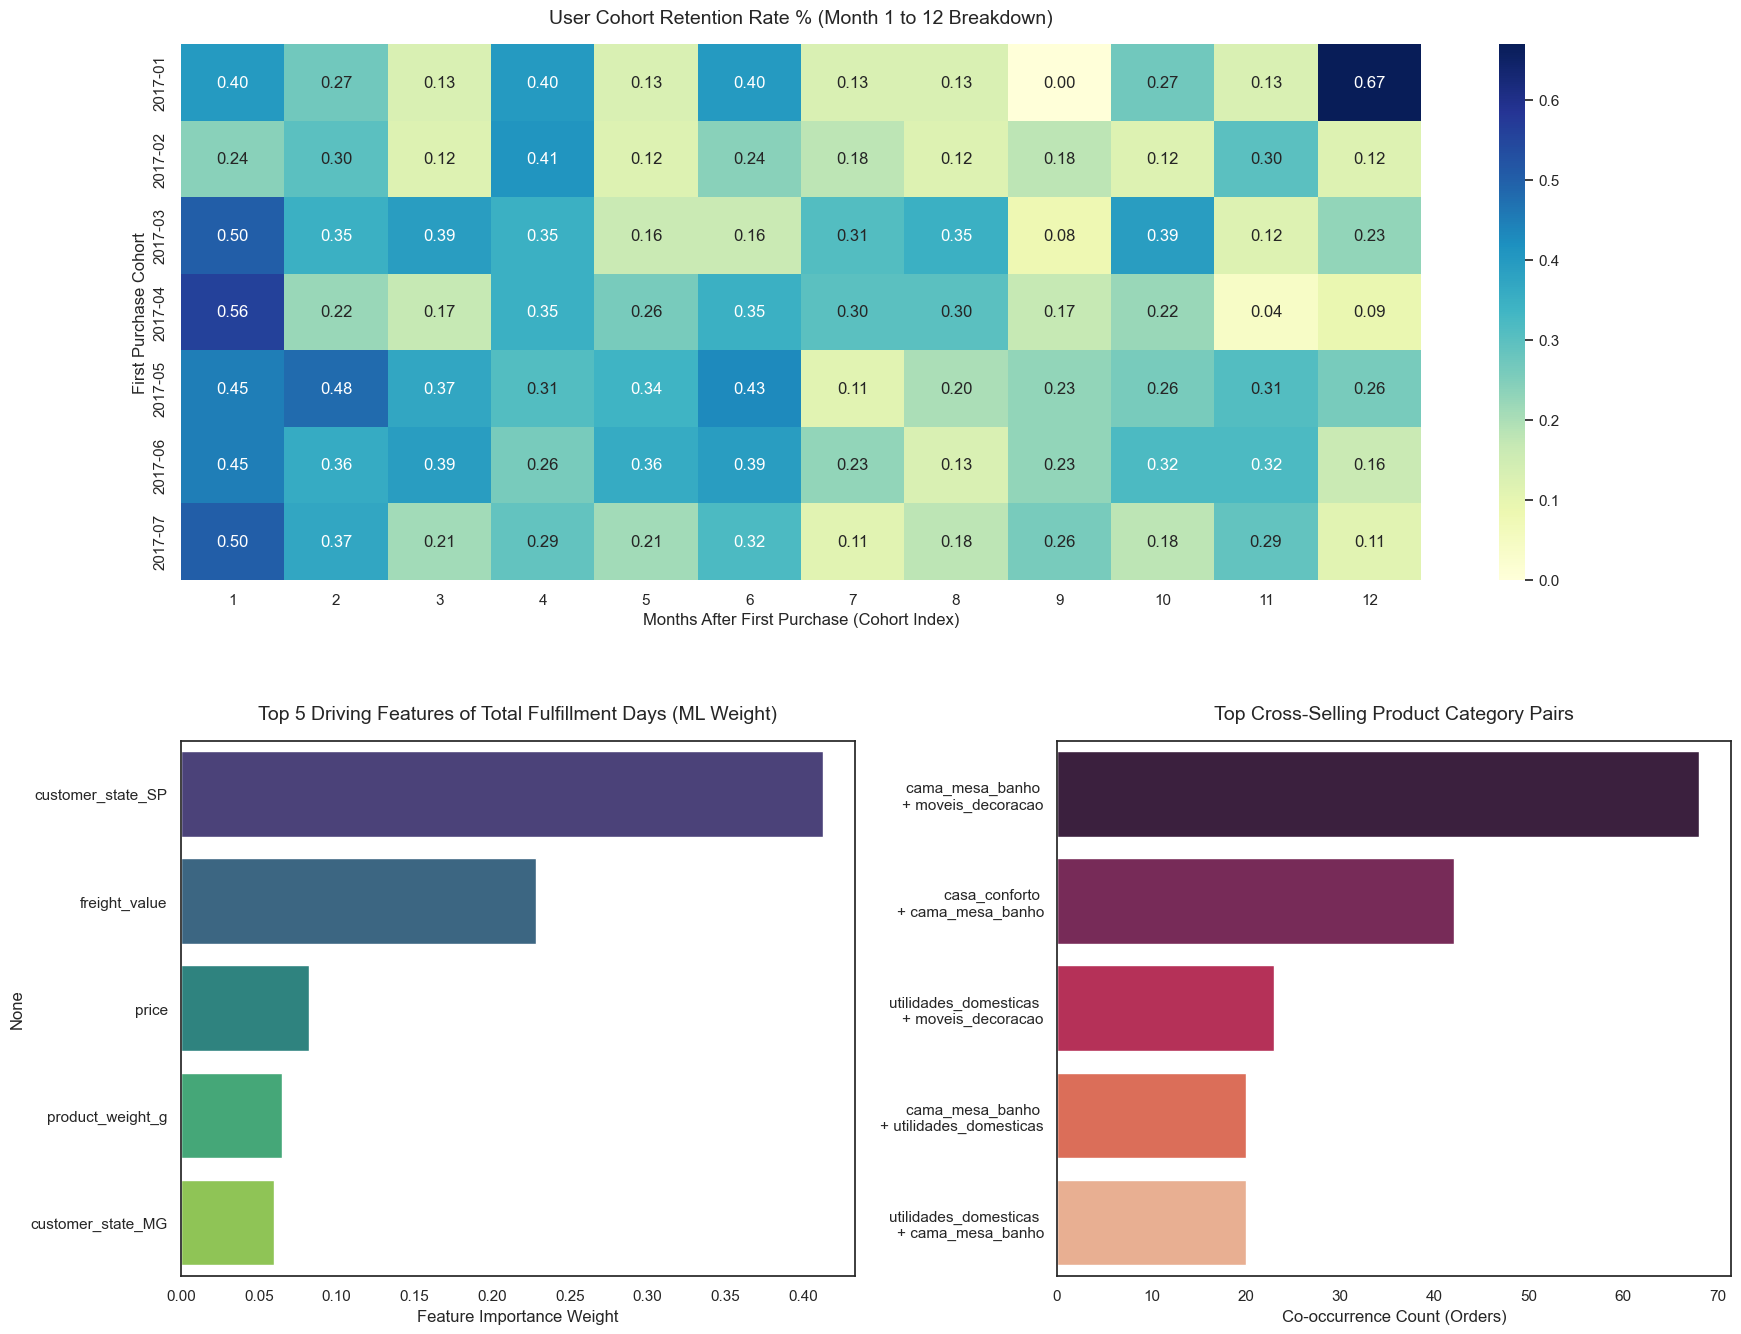

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white")

fig = plt.figure(figsize=(20, 16))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.3)

# -------------------- 1. Cohort 留存热力图 (纵向时序) --------------------
# 过滤掉全为0的测试早期月份(2016年)，只看主力运营区间，突出展示前12个月
cohort_summary = cohort_matrix.iloc[3:10, 1:13]
ax1 = fig.add_subplot(grid[0, :])
sns.heatmap(cohort_summary, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, ax=ax1)
ax1.set_title("User Cohort Retention Rate % (Month 1 to 12 Breakdown)", fontsize=14, pad=15)
ax1.set_xlabel("Months After First Purchase (Cohort Index)", fontsize=12)
ax1.set_ylabel("First Purchase Cohort", fontsize=12)

# -------------------- 2. 算法特征重要性 (因果预测) --------------------
ax2 = fig.add_subplot(grid[1, 0])
sns.barplot(x=feature_importances.head(5).values, y=feature_importances.head(5).index,
            hue=feature_importances.head(5).index, palette="viridis", legend=False, ax=ax2)
ax2.set_title("Top 5 Driving Features of Total Fulfillment Days (ML Weight)", fontsize=14, pad=15)
ax2.set_xlabel("Feature Importance Weight", fontsize=12)

# -------------------- 3. 购物篮前 5 协同频数 (交叉交叉) --------------------
ax3 = fig.add_subplot(grid[1, 1])
top_pairs = co_occurrence.head(10).iloc[::2] # 剔除A-B和B-A的重复项，只取单向
pair_labels = [f"{a} \n+ {b}" for a, b in top_pairs.index]
sns.barplot(x=top_pairs.values, y=pair_labels, hue=pair_labels, palette="rocket", legend=False, ax=ax3)
ax3.set_title("Top Cross-Selling Product Category Pairs", fontsize=14, pad=15)
ax3.set_xlabel("Co-occurrence Count (Orders)", fontsize=12)

plt.show()

In [12]:
import sys
import os
import pandas as pd

# 1. 确保将父目录加入系统路径，以便能抓到 src 文件夹
sys.path.append('../')
from src.analyzer import OlistBIEngine

# 2. 补全加载：把引擎需要的 5 张表全部安排到位
# 订单表和支付表用我们模块一清洗出来的完美 parquet 干净数据
df_orders_clean = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments_clean = pd.read_parquet("../data/processed/olist_payments_clean.parquet")

# 客户表、商品表、明细表直接读取原始的 csv
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# 3. 实例化商业智能引擎
engine = OlistBIEngine(df_orders_clean, df_payments_clean, df_customers, df_items, df_products)

# 4. 激活引擎，一键输出全套高阶指标
df_abt = engine.build_analytical_base_table()
basket_res = engine.calculate_market_basket()
cohort_res = engine.calculate_cohort_matrix()
feat_res = engine.extract_ml_feature_importance()

# 5. 打印大获成功的里程碑报告
print("=" * 50)
print("🎉 工业级 OlistBIEngine 核心引擎全面点火成功！")
print(f"👉 人货场分析大表 (ABT) 构建完毕，共生成特征样本: {len(df_abt)} 条")
print(f"👉 购物篮交叉消费对数量: {len(basket_res)} 组")
print(f"👉 客户月度留存矩阵形状: {cohort_res.shape} (月度大盘已就绪)")
print("=" * 50)

🎉 工业级 OlistBIEngine 核心引擎全面点火成功！
👉 人货场分析大表 (ABT) 构建完毕，共生成特征样本: 110715 条
👉 购物篮交叉消费对数量: 466 组
👉 客户月度留存矩阵形状: (23, 20) (月度大盘已就绪)
